In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from spatial_manifolds.detect_grids import (
    cell_classification_of1,
    compute_of_tcs,
    plot_vr_rate_map_trials_ax,
)

# Use the same source_path already defined in this notebook:
# source_path = '/Users/harryclark/Downloads/COHORT12/'

# Multishank sessions only
mouse_days = {
    21: [15,16,17,18,22,25,26],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41,42,43,44],
    25: [16,17,18,25,26],
    26: [13,15,16,19,20,21,22],
    27: [16,17,18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

# there are all the sessions
mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

'''
mouse_days = {
    26: [19,20,22],
    25: [25],
    29: [23],
}
'''

'''mouse_days = {
    25: [25],
}'''

# Boundary in SC space for medial vs lateral split
boundary = 3400  # μm

# GRID CELLS
gcs_all = []
medial_maps = []
lateral_maps = []

# NGS CELLS
ngs_all = []
medial_maps_ngs = []
lateral_maps_ngs = []

# keep track of which cells to plot in VR (GCs)
vr_cells_medial = []    # list of (mouse, day, cluster_id)
vr_cells_lateral = []

# keep track of which cells to plot in VR (NGS)
vr_ngs_medial = []      # list of (mouse, day, cluster_id)
vr_ngs_lateral = []

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing M{mouse} D{day:02}...")
        try:
            # Classify OF1 cells: grid cells + non-grid spatial cells + others
            gcs, ngs, _, _, _, all_cells = cell_classification_of1(
                mouse,
                day,
                percentile_threshold=95,
                source_path=None,
                verbose=False,
            )
        except FileNotFoundError:
            print(f"  Missing files for M{mouse} D{day:02}, skipping.")
            continue
        
        if len(gcs) == 0:
            print(f"  No grid cells for M{mouse} D{day:02}, skipping.")
            continue
        else:
            print(f"  Found {len(gcs)} grid cells for M{mouse} D{day:02}.")
            # GRID cells: SC_x flip and medial/lateral label
            gcs['SC_x_flipped'] = -gcs['SC_x']
            gcs['ml_label'] = np.where(
                gcs['SC_x_flipped'] < boundary, 'medial', 'lateral'
            )
            gcs_all.append(gcs)

            # NGS cells: SC_x flip and medial/lateral label (if any)
            if len(ngs) > 0:
                ngs = ngs.copy()
                ngs['SC_x_flipped'] = -ngs['SC_x']
                ngs['ml_label'] = np.where(
                    ngs['SC_x_flipped'] < boundary, 'medial', 'lateral'
                )
                ngs_all.append(ngs)

        # Compute open-field 2D tuning curves for this session
        tcs_of, tcs_time_of, beh_OF, clusters_OF, ep = compute_of_tcs(
            mouse,
            day,
            apply_zscore=False,          # raw rate maps
            apply_guassian_filter=True, # spatial smoothing
            fill_nans_from_neighbors=True, 
            source_path=None,
            optimal_shift=gcs.travel[0],
        )

        # --- GRID CELLS: pool OF maps + VR cells ---
        for _, row in gcs.iterrows():
            cid = int(row['cluster_id'])
            if cid not in tcs_of:
                continue

            # SC_x as defined in cell_classification_of1 (no flip there)
            scx = -row['SC_x']

            if scx < boundary:
                medial_maps.append(tcs_of[cid])
                vr_cells_medial.append((mouse, day, cid))
            else:
                lateral_maps.append(tcs_of[cid])
                vr_cells_lateral.append((mouse, day, cid))

        # --- NGS CELLS: pool OF maps + VR cells ---
        if len(ngs) > 0:
            for _, row in ngs.iterrows():
                cid = int(row['cluster_id'])
                if cid not in tcs_of:
                    continue

                scx = -row['SC_x']

                if scx < boundary:
                    medial_maps_ngs.append(tcs_of[cid])
                    vr_ngs_medial.append((mouse, day, cid))
                else:
                    lateral_maps_ngs.append(tcs_of[cid])
                    vr_ngs_lateral.append((mouse, day, cid))

# make all-groups
gcs_all = pd.concat(gcs_all, ignore_index=True)
if len(ngs_all) > 0:
    ngs_all = pd.concat(ngs_all, ignore_index=True)
else:
    ngs_all = pd.DataFrame()

# order gcs_all, ngs_all by grid_score descending (for better visualization later), also the maps
medial_maps = [x for _, x in sorted(zip(gcs_all['grid_score'], medial_maps), key=lambda pair: pair[0], reverse=True)]
lateral_maps = [x for _, x in sorted(zip(gcs_all['grid_score'], lateral_maps), key=lambda pair: pair[0], reverse=True)]
medial_maps_ngs = [x for _, x in sorted(zip(ngs_all['grid_score'], medial_maps_ngs), key=lambda pair: pair[0], reverse=True)]
lateral_maps_ngs = [x for _, x in sorted(zip(ngs_all['grid_score'], lateral_maps_ngs), key=lambda pair: pair[0], reverse=True)]
gcs_all = gcs_all.sort_values(by='grid_score', ascending=False).reset_index(drop=True)
ngs_all = ngs_all.sort_values(by='grid_score', ascending=False).reset_index(drop=True)

Processing M20 D14...
  Found 1 grid cells for M20 D14.
Processing M20 D15...
  Found 1 grid cells for M20 D15.
Processing M20 D16...
  Found 6 grid cells for M20 D16.
Processing M20 D17...
  Found 2 grid cells for M20 D17.
Processing M20 D18...
  Found 1 grid cells for M20 D18.
Processing M20 D19...
  No grid cells for M20 D19, skipping.
Processing M20 D20...
  Found 7 grid cells for M20 D20.
Processing M20 D21...
  Found 1 grid cells for M20 D21.
Processing M20 D22...
  No grid cells for M20 D22, skipping.
Processing M20 D23...
  No grid cells for M20 D23, skipping.
Processing M20 D24...
  Found 2 grid cells for M20 D24.
Processing M20 D25...
  Found 13 grid cells for M20 D25.
Processing M20 D26...
  Found 2 grid cells for M20 D26.
Processing M21 D15...
  Found 4 grid cells for M21 D15.
Processing M21 D16...
  Found 15 grid cells for M21 D16.
Processing M21 D17...
  Found 4 grid cells for M21 D17.
Processing M21 D18...
  Found 5 grid cells for M21 D18.
Processing M21 D19...
  Found 3

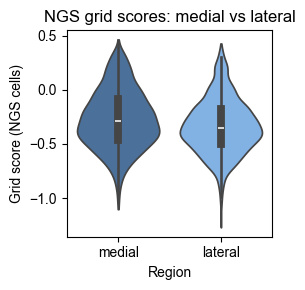

In [9]:
# Violin plot of NGS grid scores: medial vs lateral

# Ensure no NaNs in grid_score
ngs_all_clean = ngs_all.dropna(subset=["grid_score"])

plt.figure(figsize=(3, 3))
sns.violinplot(
    data=ngs_all_clean,
    x="ml_label",
    y="grid_score",
    order=["medial", "lateral"],
    palette={"medial": "#3e71a8", "lateral": "#71b1f5ff"},
    inner="box",   # show a small boxplot inside
    cut=0,         # do not extend beyond data range
)
plt.xlabel("Region")
plt.ylabel("Grid score (NGS cells)")
plt.title("NGS grid scores: medial vs lateral")
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    grid_score
No. Observations:    5032       Method:                REML      
No. Groups:          8          Scale:                 0.0650    
Min. group size:     134        Log-Likelihood:        -305.4684 
Max. group size:     1631       Converged:             Yes       
Mean group size:     629.0                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept             -0.332    0.019 -17.748 0.000 -0.369 -0.296
C(ml_label)[T.medial]  0.059    0.011   5.456 0.000  0.038  0.080
Group Var              0.002    0.006                            
mouse_day Var          0.002    0.002                            



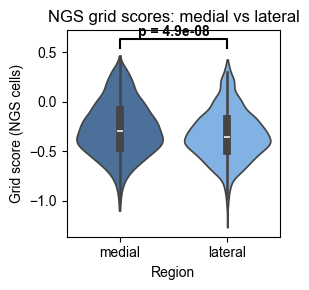

In [10]:
import statsmodels.formula.api as smf

# Ensure no NaNs in grid_score and that mouse/day are present
ngs_all_clean = ngs_all.dropna(subset=["grid_score", "mouse", "day"])

# Work on a copy
subset = ngs_all_clean.copy()

# If ml_label might be missing, (re)define it from SC_x_flipped and boundary
# boundary = 3400  # μm  (uncomment if boundary not already defined above)
# subset["ml_label"] = np.where(subset["SC_x_flipped"] < boundary, "medial", "lateral")

# Add mouse_day column for hierarchical grouping (day nested within mouse)
subset["mouse_day"] = subset["mouse"].astype(str) + "_" + subset["day"].astype(str)

# Fit LMM: grid_score ~ ml_label, with random intercepts for mouse and day (nested)
model = smf.mixedlm(
    "grid_score ~ C(ml_label)",
    subset,
    groups=subset["mouse"],
    re_formula="1",
    vc_formula={"mouse_day": "0 + C(mouse_day)"},
)
result = model.fit()
print(result.summary())

# Extract p-value for medial vs lateral effect (the coefficient involving ml_label)
effect_param = [name for name in result.params.index if "ml_label" in name][0]
pval = result.pvalues[effect_param]

# --- Violin plot of NGS grid scores: medial vs lateral, with p-value annotation ---

fig, ax = plt.subplots(figsize=(3, 3))

sns.violinplot(
    data=subset,
    x="ml_label",
    y="grid_score",
    order=["medial", "lateral"],
    palette={"medial": "#3e71a8", "lateral": "#71b1f5ff"},
    inner="box",   # show a small boxplot inside
    cut=0,         # do not extend beyond data range
    ax=ax,
)

ax.set_xlabel("Region")
ax.set_ylabel("Grid score (NGS cells)")
ax.set_title("NGS grid scores: medial vs lateral")

# Add bracket and p-value annotation between violins
x1, x2 = 0, 1  # positions of the two violins on the x-axis
ymin = subset["grid_score"].min()
ymax = subset["grid_score"].max()
dy = ymax - ymin if ymax > ymin else 1.0
h = 0.05 * dy  # height offset for the bracket

line_y = ymax + h
text_y = line_y + h

# Draw bracket
ax.plot(
    [x1, x1, x2, x2],
    [line_y, line_y + h, line_y + h, line_y],
    color="black",
    linewidth=1.5,
)

# Add p-value text centered between violins
ax.text(
    (x1 + x2) / 2,
    text_y,
    f"p = {pval:.2g}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
)

# Ensure everything is visible (extend y-limit if needed)
ax.set_ylim(top=text_y + h)

fig.tight_layout()
plt.savefig(
    "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/"
    "ngs_grid_scores_violin_medial_vs_lateral_LMM.pdf",
    dpi=500,
)
plt.show()

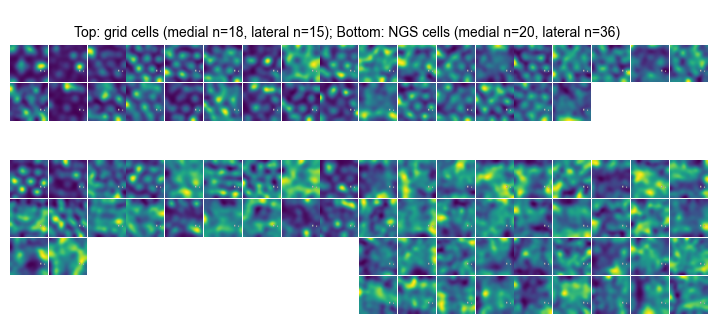

In [7]:
def plot_gc_and_ngs_of_rate_maps_medial_lateral(
    medial_maps_gc,
    lateral_maps_gc,
    medial_maps_ngs,
    lateral_maps_ngs,
    title="OF1 grid cells (top) and NGS cells (bottom): medial (left) vs lateral (right)",
    max_per_row=10,
):
    """
    Plot medial and lateral OF1 rate maps for:
      - Grid cells (top block)
      - NGS cells (bottom block)

    Layout:
      - Medial cells are on the left, lateral cells on the right.
      - Grid maps occupy the top rows, NGS maps occupy the rows below.
      - A single blank row is left between grid and NGS blocks.
      - A vertical line marks the medial–lateral division across all rows.
    """
    n_medial_gc = len(medial_maps_gc)
    n_lateral_gc = len(lateral_maps_gc)
    n_medial_ngs = len(medial_maps_ngs)
    n_lateral_ngs = len(lateral_maps_ngs)

    if any(n == 0 for n in [n_medial_gc, n_lateral_gc, n_medial_ngs, n_lateral_ngs]):
        print("Need at least one medial and one lateral cell for BOTH grid and NGS groups.")
        print(
            f"GC medial={n_medial_gc}, GC lateral={n_lateral_gc}, "
            f"NGS medial={n_medial_ngs}, NGS lateral={n_lateral_ngs}"
        )
        return

    # --- Determine rows per block (GC vs NGS) ---
    rows_gc = int(np.ceil(max(n_medial_gc, n_lateral_gc) / max_per_row))
    rows_gc = max(rows_gc, 1)

    rows_ngs = int(np.ceil(max(n_medial_ngs, n_lateral_ngs) / max_per_row))
    rows_ngs = max(rows_ngs, 1)

    # --- Determine columns for medial and lateral blocks (shared across GC and NGS) ---
    medial_cols_gc = int(np.ceil(n_medial_gc / rows_gc))
    medial_cols_ngs = int(np.ceil(n_medial_ngs / rows_ngs))
    medial_cols = max(medial_cols_gc, medial_cols_ngs)

    lateral_cols_gc = int(np.ceil(n_lateral_gc / rows_gc))
    lateral_cols_ngs = int(np.ceil(n_lateral_ngs / rows_ngs))
    lateral_cols = max(lateral_cols_gc, lateral_cols_ngs)

    ncols = medial_cols + lateral_cols

    # +1 for a blank spacer row between GC and NGS
    spacer_rows = 1
    nrows_total = rows_gc + spacer_rows + rows_ngs

    fig, axes = plt.subplots(
        nrows_total,
        ncols,
        figsize=(ncols * 0.5, nrows_total * 0.5),
        squeeze=False,
    )

    # Make gaps between subplots very small
    fig.subplots_adjust(wspace=0.02, hspace=0.02)

    # --- Top block: GRID CELLS ---
    # Medial grid cells (top-left block)
    for idx, rm in enumerate(medial_maps_gc):
        r_block = idx // medial_cols
        c = idx % medial_cols
        if r_block >= rows_gc:
            break  # safety, though it shouldn't happen
        r = r_block  # top block rows start at 0
        ax = axes[r, c]
        ax.imshow(rm, cmap="viridis", origin="lower")
        ax.axis("off")

    # Lateral grid cells (top-right block)
    for idx, rm in enumerate(lateral_maps_gc):
        r_block = idx // lateral_cols
        c = idx % lateral_cols + medial_cols
        if r_block >= rows_gc:
            break
        r = r_block
        ax = axes[r, c]
        ax.imshow(rm, cmap="viridis", origin="lower")
        ax.axis("off")

    # --- Bottom block: NGS CELLS ---
    # NGS rows start after GC rows + 1 blank spacer row
    row_offset_ngs = rows_gc + spacer_rows

    # Medial NGS cells (bottom-left block)
    for idx, rm in enumerate(medial_maps_ngs):
        r_block = idx // medial_cols
        c = idx % medial_cols
        if r_block >= rows_ngs:
            break
        r = row_offset_ngs + r_block
        ax = axes[r, c]
        ax.imshow(rm, cmap="viridis", origin="lower")
        ax.axis("off")

    # Lateral NGS cells (bottom-right block)
    for idx, rm in enumerate(lateral_maps_ngs):
        r_block = idx // lateral_cols
        c = idx % lateral_cols + medial_cols
        if r_block >= rows_ngs:
            break
        r = row_offset_ngs + r_block
        ax = axes[r, c]
        ax.imshow(rm, cmap="viridis", origin="lower")
        ax.axis("off")

    # Hide any unused axes (including the spacer row cells, which will remain blank)
    for r in range(nrows_total):
        for c in range(ncols):
            ax = axes[r, c]
            if len(ax.images) == 0:
                ax.axis("off")

    # Add a clear vertical division between medial and lateral blocks
    division_col = medial_cols  # first lateral column index
    if division_col < ncols:
        for r in range(nrows_total):
            # Right border of last medial column
            ax_left = axes[r, division_col - 1]
            ax_left.spines["right"].set_color("black")
            ax_left.spines["right"].set_linewidth(3.0)

            # Left border of first lateral column
            ax_right = axes[r, division_col]
            ax_right.spines["left"].set_color("black")
            ax_right.spines["left"].set_linewidth(3.0)

    fig.suptitle(f"\nTop: grid cells (medial n={n_medial_gc}, lateral n={n_lateral_gc}); "
        + f"Bottom: NGS cells (medial n={n_medial_ngs}, lateral n={n_lateral_ngs})",
        fontsize=10,
    )

    # Keep a little room for the title while preserving tight interior spacing
    fig.tight_layout(rect=[0, 0, 0.1, 0.6])

    plt.savefig(
        "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/"
        "M25D25_medial_lateral_grid_and_ngs_of_ratemaps.pdf",
        dpi=500,
    )
    plt.show()


# Example call using your existing maps:
plot_gc_and_ngs_of_rate_maps_medial_lateral(
    medial_maps,
    lateral_maps,
    medial_maps_ngs,
    lateral_maps_ngs,
)

In [ ]:
print(f"VR medial cells: {len(vr_cells_medial)}, VR lateral cells: {len(vr_cells_lateral)}")

def plot_vr_rate_map_grid(cells, title, ncols=10):
    """
    cells: list of (mouse, day, cluster_id) tuples
    """
    n = len(cells)
    if n == 0:
        print(f"No cells to plot for: {title}")
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 1.0, nrows * 1.0),
        squeeze=False,
    )

    for i, (mouse, day, cid) in enumerate(cells):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]
        # All VR rate-map logic lives in detect_grids.plot_vr_rate_map_trials_ax
        plot_vr_rate_map_trials_ax(
            ax=ax,
            cluster_id=cid,
            mouse=mouse,
            day=day,
            df=None,            # df argument is unused inside the function
            source_path=None,   # or your custom source_path if needed
        )
        ax.axis('off')
        #ax.set_title(f"M{mouse} D{day:02}", fontsize=6)

    # Hide unused axes
    for j in range(len(cells), nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis('off')

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# Plot all medial VR rate maps
plot_vr_rate_map_grid(
    vr_cells_medial,
    title=f"VR medial grid cells (n={len(vr_cells_medial)})",
    ncols=10,
)

# Plot all lateral VR rate maps
plot_vr_rate_map_grid(
    vr_cells_lateral,
    title=f"VR lateral grid cells (n={len(vr_cells_lateral)})",
    ncols=10,
)

# Plot all medial NGS VR rate maps
plot_vr_rate_map_grid(
    vr_ngs_medial,
    title=f"VR medial NGS cells (n={len(vr_ngs_medial)})",
    ncols=10,
)

# Plot all lateral NGS VR rate maps
plot_vr_rate_map_grid(
    vr_ngs_lateral,
    title=f"VR lateral NGS cells (n={len(vr_ngs_lateral)})",
    ncols=10,
)

In [ ]:
ngs_medial = ngs_all[ngs_all['ml_label'] == 'medial']
ngs_lateral = ngs_all[ngs_all['ml_label'] == 'lateral']
print(f' full list of grid scores for ngs medial cells (n={len(ngs_medial)}): {ngs_medial["grid_score"].tolist()}')
print(f' full list of grid scores for ngs lateral cells (n={len(ngs_lateral)}): {ngs_lateral["grid_score"].tolist()}')
print(f'grid scores for ngs medial cells: n={len(ngs_medial)}, mean={ngs_medial["grid_score"].mean():.3f}, sem={ngs_medial["grid_score"].sem():.3f}')
print(f'grid scores for ngs lateral cells: n={len(ngs_lateral)}, mean={ngs_lateral["grid_score"].mean():.3f}, sem={ngs_lateral["grid_score"].sem():.3f}')

In [ ]:
print(f"Total grid cells collected: {len(gcs_all)}")

# --- 1) Scatter: grid_score vs SC_x position ---
plt.figure(figsize=(4, 3))
sns.scatterplot(
    data=gcs_all,
    x='SC_x_flipped',
    y='grid_score',
    hue='ml_label',
    palette={'medial': '#c04744', 'lateral': "#ffcc00"},
    alpha=0.7,
    edgecolor='none',
)
plt.axvline(boundary, linestyle='--', color='black', linewidth=1)
plt.xlabel('Medial–lateral SC_x (μm, flipped)')
plt.ylabel('Grid score')
plt.title('Grid score vs SC_x position')
plt.legend(title='Region', fontsize=8)
plt.tight_layout()
plt.show()

# --- 2) Bar plot: medial vs lateral grid scores ---
plt.figure(figsize=(3, 3))
sns.barplot(
    data=gcs_all,
    x='ml_label',
    y='grid_score',
    order=['medial', 'lateral'],
    palette={'medial': '#c04744', 'lateral': "#b9b115"},
    ci=68,  # ~SEM
)
plt.xlabel('Region')
plt.ylabel('Grid score')
plt.title('Mean grid score: medial vs lateral')
plt.tight_layout()
plt.show()